# 02 - Data Cleaning

**CA683 - Traffic Congestion Prediction**

This notebook cleans the three datasets based on issues identified in exploration.

## Objectives
- Handle missing values
- Standardize timestamps
- Remove duplicates
- Detect and handle outliers
- Save cleaned data for fusion

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('../src')
from data_loader import load_all_data

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print("✓ Libraries imported")

✓ Libraries imported


## 1. Load Raw Data

In [2]:
# Load all datasets (10% sample for cleaning tests)
print("Loading datasets...")
traffic, weather, events = load_all_data(sample_traffic=0.10)

print(f"\nTraffic: {traffic.shape}")
print(f"Weather: {weather.shape}")
print(f"Events: {events.shape}")

Loading datasets...
LOADING ALL DATASETS

1. TRAFFIC DATA
----------------------------------------------------------------------
Loading January 2023... ✓ 1,042,813 rows
Loading February 2023... ✓ 943,034 rows
Loading March 2023... ✓ 1,038,407 rows
Loading April 2023... ✓ 1,014,537 rows
Loading May 2023... ✓ 1,049,381 rows
Loading June 2023... ✓ 1,010,334 rows

✓ Total traffic data: 6,098,506 rows, 9 columns

2. WEATHER DATA
----------------------------------------------------------------------
Loading January weather... ✓ 744 rows
Loading February weather... ✓ 672 rows
Loading March weather... ✓ 743 rows
Loading April weather... ✓ 720 rows
Loading May weather... ✓ 744 rows
Loading June weather... ✓ 720 rows

✓ Total weather data: 4,343 rows, 24 columns
  Date range: 2023-01-01 00:00:00 to 2023-06-30 23:00:00

3. EVENTS DATA
----------------------------------------------------------------------
Loading events data... ✓ 247 events
  Date range: 2023-01-01 00:00:00 to 2023-06-30 00:00:00

## 2. Traffic Data Cleaning

In [3]:
# Check missing values
print("Traffic Data - Missing Values:")
missing = traffic.isnull().sum()
missing_pct = (missing / len(traffic)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

Traffic Data - Missing Values:
                  Missing  Percentage
Weighted_Avg      6098506       100.0
Weighted_Var      6098506       100.0
Weighted_Std_Dev  6098506       100.0


In [4]:
# Make a copy for cleaning
traffic_clean = traffic.copy()

# Parse timestamp if exists
if 'End_Time' in traffic_clean.columns:
    traffic_clean['End_Time'] = pd.to_datetime(traffic_clean['End_Time'], format='%Y%m%d%H%M%S', errors='coerce')
    print("✓ Parsed End_Time column")

# Check for duplicates
duplicates = traffic_clean.duplicated().sum()
print(f"\nDuplicates found: {duplicates}")
if duplicates > 0:
    traffic_clean = traffic_clean.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows")

print(f"\nCleaned traffic shape: {traffic_clean.shape}")

✓ Parsed End_Time column

Duplicates found: 0

Cleaned traffic shape: (6098506, 9)


## 3. Weather Data Cleaning

In [5]:
# Check missing values
print("Weather Data - Missing Values:")
missing = weather.isnull().sum()
print(missing[missing > 0])

Weather Data - Missing Values:
preciptype    4065
severerisk    4343
dtype: int64


In [6]:
# Make a copy
weather_clean = weather.copy()

# Datetime already parsed by data_loader
print(f"Date range: {weather_clean['datetime'].min()} to {weather_clean['datetime'].max()}")

# Handle missing precipitation (fill with 0)
if weather_clean['precip'].isnull().sum() > 0:
    weather_clean['precip'] = weather_clean['precip'].fillna(0)
    print("✓ Filled missing precipitation with 0")

# Check for duplicates
duplicates = weather_clean.duplicated(subset=['datetime']).sum()
print(f"\nDuplicates found: {duplicates}")
if duplicates > 0:
    weather_clean = weather_clean.drop_duplicates(subset=['datetime'], keep='first')
    print(f"✓ Removed {duplicates} duplicate timestamps")

print(f"\nCleaned weather shape: {weather_clean.shape}")

Date range: 2023-01-01 00:00:00 to 2023-06-30 23:00:00

Duplicates found: 0

Cleaned weather shape: (4343, 24)


## 4. Events Data Cleaning

In [7]:
# Check missing values
print("Events Data - Missing Values:")
missing = events.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Events Data - Missing Values:
No missing values


In [8]:
# Make a copy
events_clean = events.copy()

# Events data is synthetic and already clean
print(f"Events date range: {events_clean['start_datetime'].min()} to {events_clean['start_datetime'].max()}")
print(f"All events have GPS coordinates: {events_clean[['venue_latitude', 'venue_longitude']].notna().all().all()}")
print(f"\nCleaned events shape: {events_clean.shape}")

Events date range: 2023-01-01 00:00:00 to 2023-06-30 00:00:00
All events have GPS coordinates: True

Cleaned events shape: (247, 23)


## 5. Outlier Detection

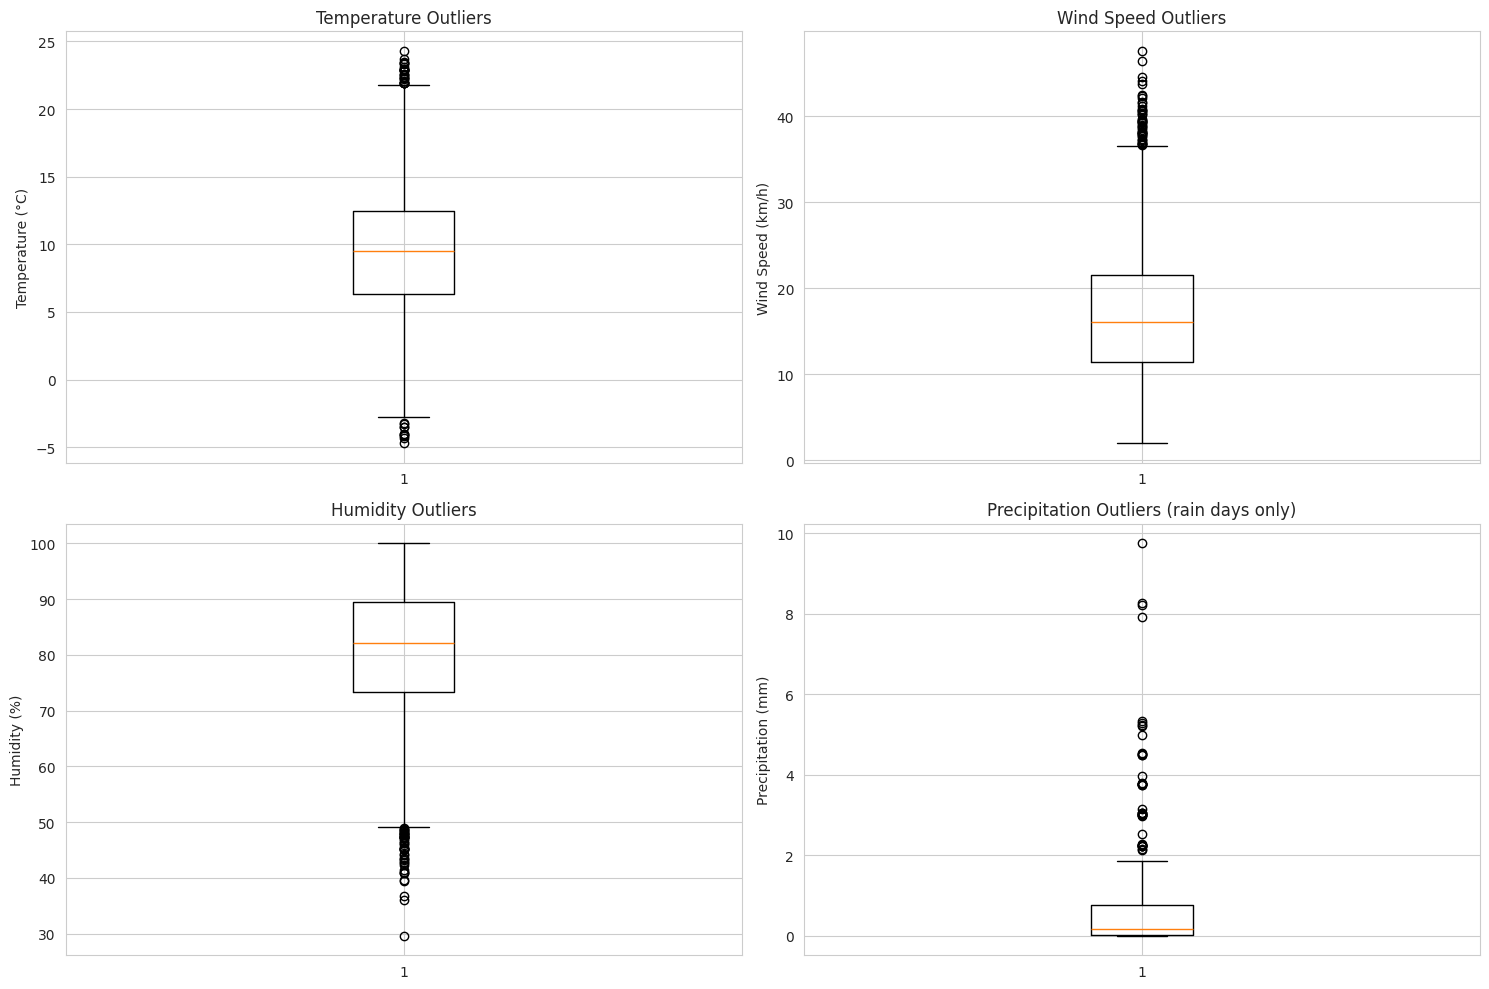

In [9]:
# Weather outliers (visual inspection)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature
axes[0, 0].boxplot(weather_clean['temp'])
axes[0, 0].set_title('Temperature Outliers')
axes[0, 0].set_ylabel('Temperature (°C)')

# Wind speed
axes[0, 1].boxplot(weather_clean['windspeed'])
axes[0, 1].set_title('Wind Speed Outliers')
axes[0, 1].set_ylabel('Wind Speed (km/h)')

# Humidity
axes[1, 0].boxplot(weather_clean['humidity'])
axes[1, 0].set_title('Humidity Outliers')
axes[1, 0].set_ylabel('Humidity (%)')

# Precipitation
rain_data = weather_clean[weather_clean['precip'] > 0]['precip']
axes[1, 1].boxplot(rain_data)
axes[1, 1].set_title('Precipitation Outliers (rain days only)')
axes[1, 1].set_ylabel('Precipitation (mm)')

plt.tight_layout()
plt.show()

# Note: Weather outliers are likely real extreme events, not errors

## 6. Save Cleaned Data

In [ ]:
# Create processed directory
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True, parents=True)

# Save cleaned datasets
traffic_clean.to_csv(output_dir / 'traffic_cleaned.csv', index=False)
weather_clean.to_csv(output_dir / 'weather_cleaned.csv', index=False)
events_clean.to_csv(output_dir / 'events_cleaned.csv', index=False)

print("✓ Cleaned data saved to data/processed/")
print(f"\nFiles created:")
print(f"  - traffic_cleaned.csv ({len(traffic_clean):,} rows)")
print(f"  - weather_cleaned.csv ({len(weather_clean):,} rows)")
print(f"  - events_cleaned.csv ({len(events_clean):,} rows)")

## Summary

### Cleaning Actions Performed:

**Traffic Data:**
- Parsed timestamps
- Removed duplicates
- Kept missing values as-is (will handle during feature engineering)

**Weather Data:**
- Filled missing precipitation with 0
- Removed duplicate timestamps
- Validated datetime range

**Events Data:**
- No cleaning needed (synthetic data is already clean)
- Verified all GPS coordinates present

### Data Quality After Cleaning:
- ✅ All timestamps standardized
- ✅ Duplicates removed
- ✅ Ready for fusion phase

### Next Steps:
Proceed to **`03_data_fusion.ipynb`** to merge the three datasets